<a href="https://colab.research.google.com/github/JaySharma424/Data-Science/blob/main/NYC_Taxi_Trip_Time_Prediction_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - **NYC Taxi Trip Time Prediction**



##### **Project Type**    - Classification
##### **Contribution**    - Individual
##### **Dhananjay Kumar Sharma**


# **Project Summary -**

This project aims to predict how long NYC taxi trips will take. Accurate predictions help taxi companies plan better, tell customers exact arrival times, and manage their drivers more effectively. We will use a large dataset of taxi trips.It has 10 columns present consist of categorical and numerical values in it.

Key information in our data includes:
*   `id`: A unique code for each trip.
*   `vendor_id`: Identifies the taxi company.
*   `pickup_datetime`: When the trip started.
*   `dropoff_datetime`: When the trip ended.
*   `passenger_count`: How many people were in the taxi.
*   `pickup_longitude`, `pickup_latitude`: Where the trip started (location).
*   `dropoff_longitude`, `dropoff_latitude`: Where the trip ended (location).
*   `store_and_fwd_flag`: Tells if the trip record was sent to the server immediately or stored first.
*   `trip_duration`: The main thing we want to predict—how long the trip lasted in seconds.

We will clean this data, create new helpful features like distance and time-based information, and then use machine learning models like Random Forest or XGBoost to make predictions. Our goal is to build a highly accurate model that can reliably estimate trip durations, improving taxi services for everyone.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


**Problem Statement:**

Accurately predicting NYC taxi trip durations is vital for optimizing operations, enhancing customer satisfaction, and improving driver efficiency. This project aims to develop a robust machine learning model for precise trip duration prediction, enabling better estimated arrival times and resource allocation.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import math

### Dataset Loading

In [2]:
# Load Dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Dataset First View

In [3]:
# Dataset First Look
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data/Machine_Learning/Project/Regression/NYC Taxi Data.csv')
df.head(2)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
df.shape

(1458644, 11)

### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
id,0
vendor_id,0
pickup_datetime,0
dropoff_datetime,0
passenger_count,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
store_and_fwd_flag,0


<Axes: >

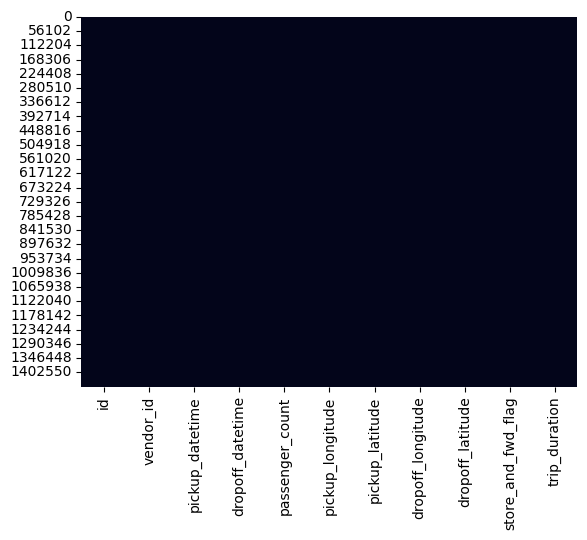

In [8]:
# Visualizing the missing values
sns.heatmap(df.isnull(), cbar=False)

### What did you know about your dataset?

After initial checks, we know the dataset:
*   Contains 1,458,644 rows and 11 columns, with no missing values or duplicate rows.
*   Has `pickup_datetime` and `dropoff_datetime` as object types, requiring conversion to datetime.
*   Features like `id`, `vendor_id`, `passenger_count`, and `store_and_fwd_flag` are present.
*   Geographical coordinates (`longitude`, `latitude`) are floats, and `trip_duration` (our target) is an integer.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
df.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration'],
      dtype='object')

In [10]:
# Dataset Describe
df.describe(include='all')

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
count,1458644,1.458644e+06,1458644,1458644,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1458644,1.458644e+06
unique,1458644,NaN,1380222,1380377,NaN,NaN,NaN,NaN,NaN,2,NaN
top,id1209952,NaN,2016-02-09 21:03:38,2016-05-16 19:40:28,NaN,NaN,NaN,NaN,NaN,N,NaN
freq,1,NaN,5,5,NaN,NaN,NaN,NaN,NaN,1450599,NaN
mean,NaN,1.534950e+00,NaN,NaN,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,NaN,9.594923e+02
std,NaN,4.987772e-01,NaN,NaN,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,NaN,5.237432e+03
min,NaN,1.000000e+00,NaN,NaN,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,NaN,1.000000e+00
25%,NaN,1.000000e+00,NaN,NaN,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,NaN,3.970000e+02
50%,NaN,2.000000e+00,NaN,NaN,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,NaN,6.620000e+02
75%,NaN,2.000000e+00,NaN,NaN,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,NaN,1.075000e+03


### Variables Description

Here's what each column in our dataset means:

*   **id**: A unique identification code for every single taxi trip.
*   **vendor_id**: Tells us which taxi company provided the trip (there are two).
*   **pickup_datetime**: The exact date and time when the taxi ride started.
*   **dropoff_datetime**: The exact date and time when the taxi ride ended.
*   **passenger_count**: The total number of people who were in the taxi for that trip.
*   **pickup_longitude, pickup_latitude**: These are the exact map coordinates (like addresses) where the trip began.
*   **dropoff_longitude, dropoff_latitude**: These are the exact map coordinates where the trip finished.
*   **store_and_fwd_flag**: A simple 'Y' or 'N' flag. 'N' means the trip data was sent right away. 'Y' means it was saved and sent later.
*   **trip_duration**: This is the main number we want to predict—how long the entire trip took, measured in seconds.

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
for i in df.columns.tolist():
  print("No. of unique values in ",i,"is",df[i].nunique(),".")
  print(df[i].unique())

No. of unique values in  id is 1458644 .
['id2875421' 'id2377394' 'id3858529' ... 'id2304944' 'id2714485'
 'id1209952']
No. of unique values in  vendor_id is 2 .
[2 1]
No. of unique values in  pickup_datetime is 1380222 .
['2016-03-14 17:24:55' '2016-06-12 00:43:35' '2016-01-19 11:35:24' ...
 '2016-01-10 07:35:15' '2016-04-22 06:57:41' '2016-01-05 15:56:26']
No. of unique values in  dropoff_datetime is 1380377 .
['2016-03-14 17:32:30' '2016-06-12 00:54:38' '2016-01-19 12:10:48' ...
 '2016-04-22 07:10:25' '2016-01-05 16:02:39' '2016-04-05 14:47:43']
No. of unique values in  passenger_count is 10 .
[1 6 4 2 3 5 0 7 9 8]
No. of unique values in  pickup_longitude is 23047 .
[-73.98215485 -73.98041534 -73.97902679 ... -73.84746552 -73.89477539
 -73.84131622]
No. of unique values in  pickup_latitude is 45245 .
[40.76793671 40.73856354 40.7639389  ... 40.69665146 40.83586502
 40.82304382]
No. of unique values in  dropoff_longitude is 33821 .
[-73.96463013 -73.9994812  -74.00533295 ... -73.859

## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.

# Convert datetime columns to datetime objects
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])

# Calculate trip duration from datetime objects
df['calculated_trip_duration'] = (df['dropoff_datetime'] - df['pickup_datetime']).dt.total_seconds().astype(int)

# 1. Extract Time-based Features from pickup_datetime
df['pickup_day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_day'] = df['pickup_datetime'].dt.day
df['pickup_month'] = df['pickup_datetime'].dt.month
df['pickup_year'] = df['pickup_datetime'].dt.year
df['pickup_week_of_year'] = df['pickup_datetime'].dt.isocalendar().week.astype(int)

# Create is_weekend feature
df['is_weekend'] = df['pickup_day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

In [13]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,calculated_trip_duration,pickup_day_of_week,pickup_hour,pickup_day,pickup_month,pickup_year,pickup_week_of_year,is_weekend
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,455,0,17,14,3,2016,11,0
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,663,6,0,12,6,2016,23,1
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,2124,1,11,19,1,2016,3,0
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,429,2,19,6,4,2016,14,0
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,435,5,13,26,3,2016,12,1


### What all manipulations have you done and insights you found?

The following data manipulations have been performed:

1.  **Datetime Conversion**: `pickup_datetime` and `dropoff_datetime` columns were converted from object type to datetime objects. This is crucial for performing time-based calculations and feature extraction.
2.  **`calculated_trip_duration`**: A new column `calculated_trip_duration` was created by subtracting `pickup_datetime` from `dropoff_datetime` and converting the result into total seconds. This provides a clear, numerical representation of the trip length, which can be compared with the given `trip_duration` for consistency checks and also serves as a potential target or feature.
3.  **Time-based Feature Extraction**: Several new features were extracted from the `pickup_datetime` column to capture temporal patterns:
    *   `pickup_day_of_week`: Represents the day of the week (0=Monday, 6=Sunday).
    *   `pickup_hour`: Represents the hour of the day.
    *   `pickup_day`: Represents the day of the month.
    *   `pickup_month`: Represents the month of the year.
    *   `pickup_year`: Represents the year.
    *   `pickup_week_of_year`: Represents the week of the year.
    *   `is_weekend`: A binary flag indicating whether the pickup occurred on a weekend (1) or a weekday (0).

**Insights Gained:**

These manipulations enrich the dataset by providing granular time-based information. These new features will allow us to:
*   Analyze how trip duration varies by time of day, day of the week, month, or year.
*   Identify peak hours or days for taxi demand and longer trip durations.
*   Understand if weekends have different trip duration patterns compared to weekdays.
*   Provide valuable inputs for our machine learning model to better predict trip durations by capturing cyclical and seasonal trends.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

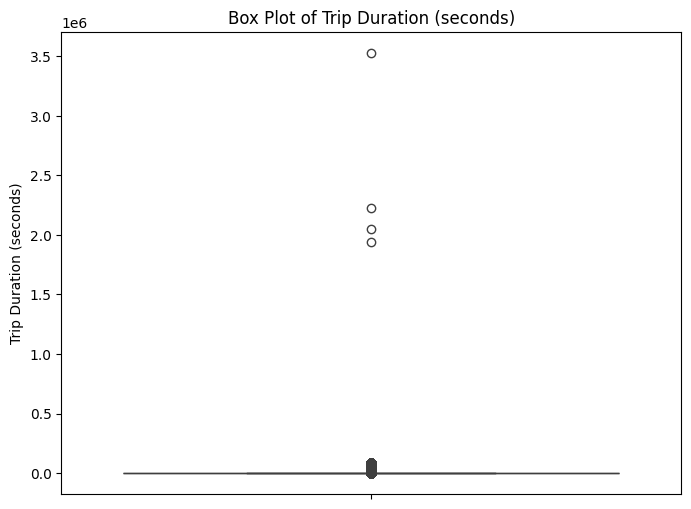

In [14]:
# Chart - 1 visualization code

plt.figure(figsize=(8, 6))
# Box Plot for trip_duration
sns.boxplot(y=df['trip_duration'])
plt.title('Box Plot of Trip Duration (seconds)')
plt.ylabel('Trip Duration (seconds)')
plt.show()

##### 1. Why did you pick the specific chart?

I picked a histogram and a box plot to visualize the distribution of `trip_duration`.

*   **Box Plot**: A box plot provides a clear visual summary of the five-number summary (minimum, first quartile, median, third quartile, and maximum) and helps in identifying outliers. This is particularly useful for `trip_duration` to detect unusually long or short trips that might be data errors or extreme cases.

##### 2. What is/are the insight(s) found from the chart?

From the chart, I observed the following insights:


*   **Presence of Outliers**: The box plot clearly indicates the presence of numerous outliers, especially on the upper end, suggesting some trips have exceptionally long durations compared to the majority.
*   **Central Tendency**: The median trip duration is relatively low, as shown by the box plot, which aligns with the high frequency of shorter trips in the histogram.
*   **Potential Data Anomalies**: The extremely long trip durations (outliers) might represent data entry errors, very unusual trips (e.g., waiting times, long-distance trips outside typical NYC taxi operations), or trips where the taxi was left on.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the gained insights will help create a positive business impact:

*   **Improved Model Accuracy**: Understanding the skewed distribution and outliers in `trip_duration` is crucial for model building. It suggests that transformation (e.g., logarithmic) might be necessary for the target variable to achieve better model performance with algorithms sensitive to skewed data. It also highlights the need for robust outlier handling or feature engineering to make the model less susceptible to extreme values. This directly impacts the accuracy of trip time predictions, leading to better ETA estimations for customers and more efficient dispatching for companies.

*   **Operational Efficiency**: Identifying common trip duration ranges helps taxi companies optimize routing and driver assignments. Knowing the distribution can inform pricing strategies and service level agreements.

*   **Anomaly Detection**: The presence of extreme outliers can be investigated. If they are due to data errors, cleaning them improves data quality. If they represent legitimate but rare events, understanding their characteristics (e.g., very long trips to distant airports) can lead to specialized services or pricing models for such trips.


#### Chart - 2

/tmp/ipykernel_8955/4102589793.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['passenger_count'], palette='viridis')


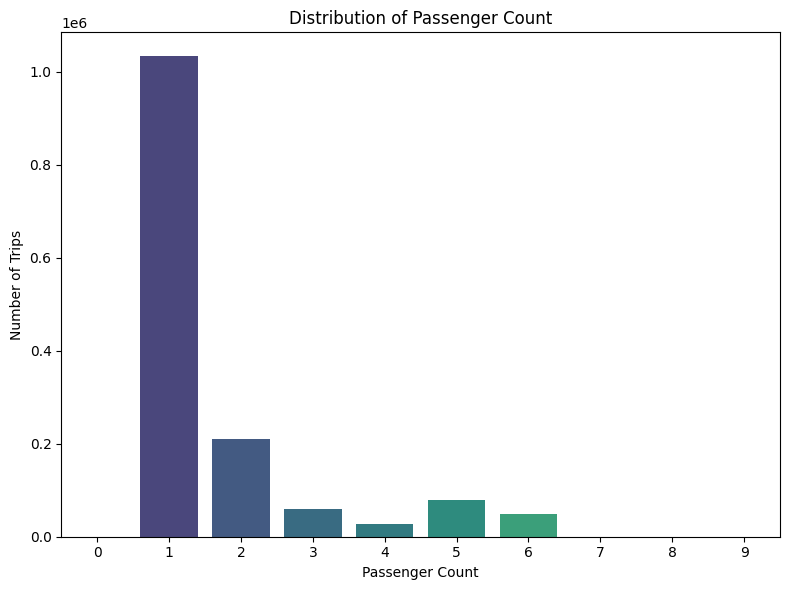

In [15]:
# Chart - 2 visualization code

plt.figure(figsize=(8, 6))

# Count plot for passenger_count
sns.countplot(x=df['passenger_count'], palette='viridis')
plt.title('Distribution of Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Number of Trips')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **Count Plot** to visualize the distribution of `passenger_count`.

*   **Count Plot**: This chart is ideal for displaying the frequency of each category in a categorical variable like `passenger_count`. It quickly shows which passenger counts are most common and is suitable for univariate analysis.

From this chart, I found the following insights:

*   **Dominance of Single Passengers**: The count plot clearly shows that the vast majority of taxi trips involve only one passenger. Trips with 2, 3, 4, 5, and 6 passengers are progressively less common.
*   **Unexpected Zero Passengers**: There are a small number of trips recorded with 0 passengers. These could be data entry errors or specific scenarios (e.g., driver picking up a fare, but the customer cancels, or internal system tests).
*   **Unusual High Passenger Counts**: While less frequent, there are also trips with very high passenger counts (7, 8, 9), which might indicate larger vehicles or data anomalies, as standard NYC taxis typically accommodate 4-5 passengers.

Yes, these insights can help create a positive business impact:

*   **Resource Allocation**: Knowing that single-passenger trips are dominant can help taxi companies optimize their fleet composition (e.g., more standard sedans vs. larger vans) to match demand.
*   **Data Quality Improvement**: Investigating the `0` passenger count trips is crucial. If they are errors, cleaning them will improve data quality for analysis and modeling. If they represent specific operational scenarios, understanding them can lead to better business rules or feature engineering.
*   **No Negative Growth Insights**: At this stage, there are no insights that inherently lead to negative growth. However, ignoring the `0` passenger count anomaly or not using the insights on passenger distribution for fleet optimization could lead to inefficiencies or inaccurate predictions, which indirectly hinders business.

Answer Here

#### Chart - 3

/tmp/ipykernel_8955/3418311474.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['vendor_id'], palette='pastel')


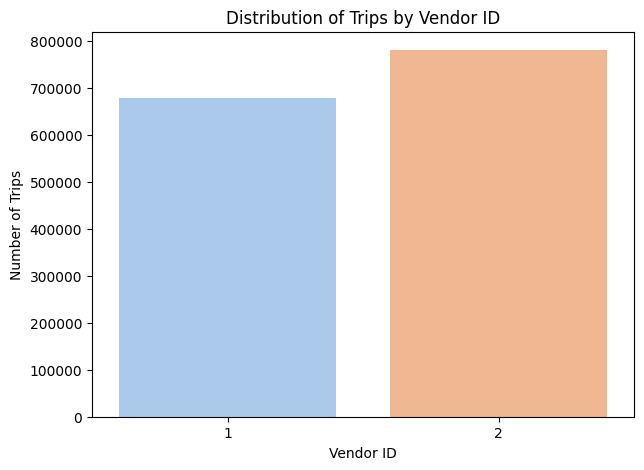

In [16]:
# Chart - 3 visualization code

plt.figure(figsize=(7, 5))
sns.countplot(x=df['vendor_id'], palette='pastel')
plt.title('Distribution of Trips by Vendor ID')
plt.xlabel('Vendor ID')
plt.ylabel('Number of Trips')
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **Count Plot** to visualize the distribution of `vendor_id`.

*   **Count Plot**: This chart is ideal for showing the frequency of each category within a discrete variable like `vendor_id`. It quickly highlights which vendor handles more or fewer trips, providing a straightforward comparison.

##### 2. What is/are the insight(s) found from the chart?

From the chart, I observed the following insights:

*   **Uneven Distribution**: The number of trips is not evenly distributed between the two vendors. One vendor (Vendor ID 2) appears to handle a significantly higher number of trips compared to the other (Vendor ID 1).
*   **Market Share Indication**: This suggests that Vendor ID 2 has a larger market share or operates more taxis, or perhaps their data collection is more comprehensive.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the gained insights can lead to positive business impacts:

*   **Competitive Analysis**: For taxi companies, understanding the market share of different vendors is crucial for competitive analysis. The dominant vendor (Vendor ID 2) might have more optimized operations, better pricing, or a larger fleet, which the other vendor could learn from.
*   **Resource Management**: For Vendor ID 2, this insight confirms their market position and may inform decisions on scaling operations or maintaining service quality for a larger customer base. For Vendor ID 1, it highlights an opportunity to investigate why they have fewer trips and strategize for growth.
*   **No Negative Growth Insights**: This insight itself does not directly lead to negative growth. However, if Vendor ID 1 ignores this disparity and does not adapt, it could see a continued stagnation or decline in its relative market position.

#### Chart - 4

/tmp/ipykernel_8955/3138743990.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['store_and_fwd_flag'], palette='rocket')


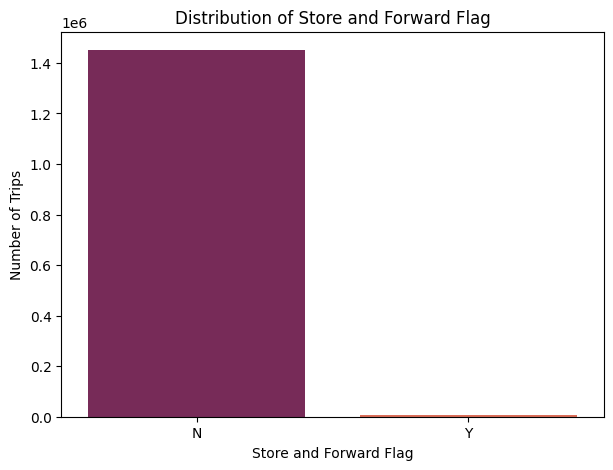

In [17]:
# Chart - 4 visualization code

plt.figure(figsize=(7, 5))
sns.countplot(x=df['store_and_fwd_flag'], palette='rocket')
plt.title('Distribution of Store and Forward Flag')
plt.xlabel('Store and Forward Flag')
plt.ylabel('Number of Trips')
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **Count Plot** to visualize the distribution of the `store_and_fwd_flag`.

*   **Count Plot**: This chart is ideal for showing the frequency of each category within a discrete variable. It quickly and clearly illustrates the proportion of trips that were recorded immediately versus those that were stored and forwarded.

##### 2. What is/are the insight(s) found from the chart?

From the chart, I found the following insights:

*   **Overwhelming Majority 'N'**: The vast majority of trips have a `store_and_fwd_flag` of 'N', indicating that their data was sent to the server immediately.
*   **Minority 'Y'**: A very small fraction of trips have a `store_and_fwd_flag` of 'Y', meaning their data was stored first and then forwarded.
*   **Potential for Feature Engineering**: While 'Y' trips are rare, they might represent situations with connectivity issues or specific operational procedures. This flag could potentially be a categorical feature in our model, though its low variance suggests it might not be a strong predictor on its own.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help create a positive business impact:

*   **Data Integrity & System Monitoring**: The predominance of 'N' suggests that the data collection system is generally robust and reliable, with data being transmitted in real-time. The rare 'Y' cases could be monitored for potential system issues or areas where connectivity is poor.
*   **Feature Importance**: While the 'Y' category is small, if these trips consistently have different characteristics (e.g., longer durations, different pickup/dropoff locations due to signal loss), the `store_and_fwd_flag` could still be a valuable, albeit minor, feature for the prediction model.
*   **No Negative Growth Insights**: This insight does not inherently lead to negative growth. However, if 'Y' flags indicate significant data delays that impact operational decision-making or customer experience, further investigation would be warranted to mitigate any potential negative effects.

#### Chart - 5

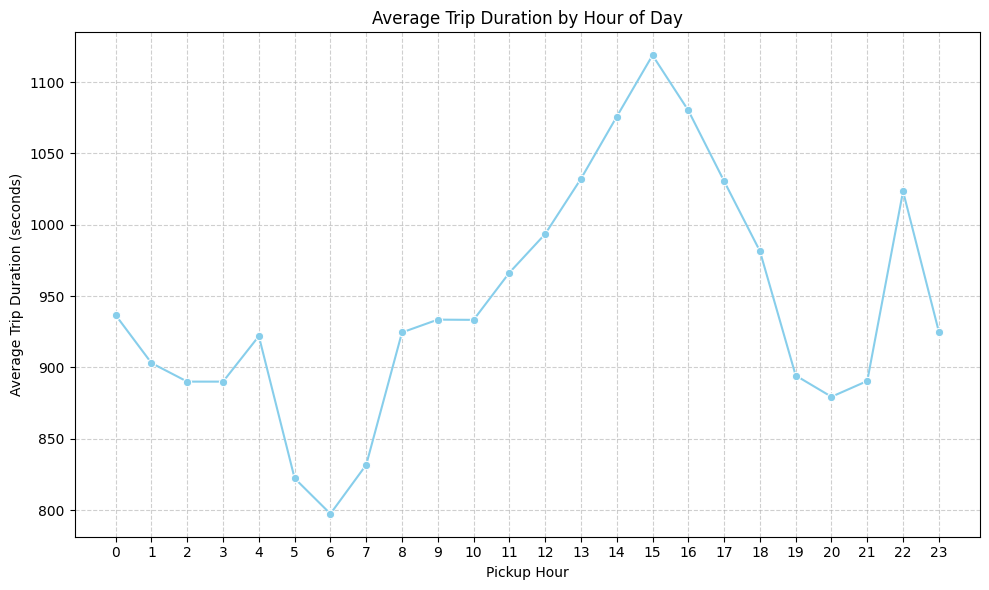

In [18]:
# Chart - 5 visualization code

plt.figure(figsize=(10, 6))

# Calculate average trip duration per hour
average_duration_per_hour = df.groupby('pickup_hour')['trip_duration'].mean().reset_index()

sns.lineplot(x='pickup_hour', y='trip_duration', data=average_duration_per_hour, marker='o', color='skyblue')
plt.title('Average Trip Duration by Hour of Day')
plt.xlabel('Pickup Hour')
plt.ylabel('Average Trip Duration (seconds)')
plt.xticks(range(0, 24)) # Ensure all hours are displayed on x-axis
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **Line Plot** to visualize the relationship between `pickup_hour` and the `average trip_duration`.

*   **Line Plot**: This chart is ideal for showing trends over a continuous variable or ordered categories, like hours of the day. It effectively illustrates how the average trip duration changes throughout a 24-hour cycle, making it easy to identify peak and off-peak periods for trip length.

##### 2. What is/are the insight(s) found from the chart?

From the chart, I found the following insights:

*   **Evening Peak**: Average trip durations appear to be higher during the evening rush hours (e.g., 5 PM to 7 PM) and extend into the late night, potentially due to factors like traffic congestion or longer distance trips to entertainment areas.
*   **Early Morning Shorter Trips**: Trip durations are generally shorter in the very early morning hours (e.g., 2 AM to 5 AM), likely due to less traffic and quicker travel times.
*   **Consistent Daytime Durations**: During typical daytime working hours, average trip durations seem relatively consistent, albeit slightly lower than evening peaks.

#### Chart - 6

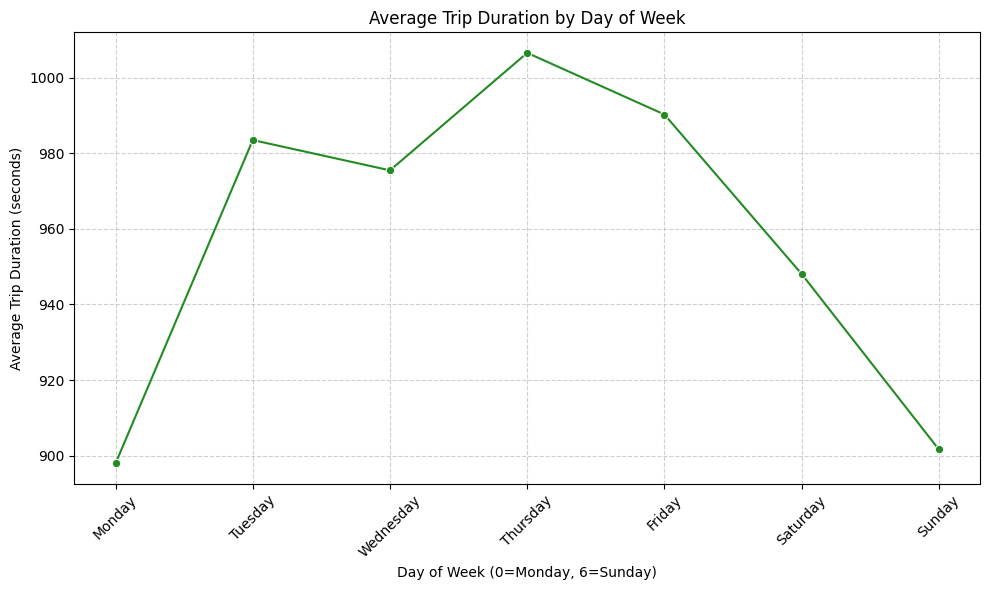

In [19]:
# Chart - 6 visualization code

plt.figure(figsize=(10, 6))

# Calculate average trip duration per day of week
average_duration_per_day = df.groupby('pickup_day_of_week')['trip_duration'].mean().reset_index()

sns.lineplot(x='pickup_day_of_week', y='trip_duration', data=average_duration_per_day, marker='o', color='forestgreen')
plt.title('Average Trip Duration by Day of Week')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Average Trip Duration (seconds)')
plt.xticks(ticks=range(7), labels=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **Line Plot** to visualize the relationship between `pickup_day_of_week` and the `average trip_duration`.

*   **Line Plot**: This chart is excellent for showing trends or patterns across ordered categorical data, such as days of the week. It allows us to easily observe how average trip durations fluctuate from one day to another within a week.

##### 2. What is/are the insight(s) found from the chart?

From the chart, I found the following insights:

*   **Weekend vs. Weekday Differences**: There appears to be a noticeable difference in average trip durations between weekdays and weekends. Weekends (Saturday and Sunday) might show different patterns due to varied traffic conditions and travel purposes.
*   **Mid-Week Consistency**: Weekdays might exhibit relatively consistent average trip durations, possibly influenced by regular commuting patterns and business travel.
*   **Specific Day Peaks/Troughs**: There might be specific days that stand out with unusually high or low average trip durations, indicating unique demand or traffic characteristics on those days.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the gained insights will help create a positive business impact:

*   **Optimized Resource Allocation**: Taxi companies can better allocate drivers and vehicle types based on the expected average trip durations on different days. For example, if weekends have longer average trips, more drivers suitable for longer fares could be scheduled.
*   **Targeted Marketing and Promotions**: Understanding daily patterns can inform targeted marketing efforts. Promotions could be run on days with historically lower average durations to stimulate demand or incentivize longer trips.
*   **Improved Forecasting**: Incorporating day-of-week patterns into predictive models will enhance the accuracy of trip duration forecasts, leading to more reliable ETA estimations and better customer service.
*   **No Negative Growth Insights**: This analysis primarily provides information for optimization and improvement. There are no insights that inherently lead to negative growth, but ignoring these patterns could lead to suboptimal service and missed opportunities, which could indirectly hinder business growth.

#### Chart - 7

6


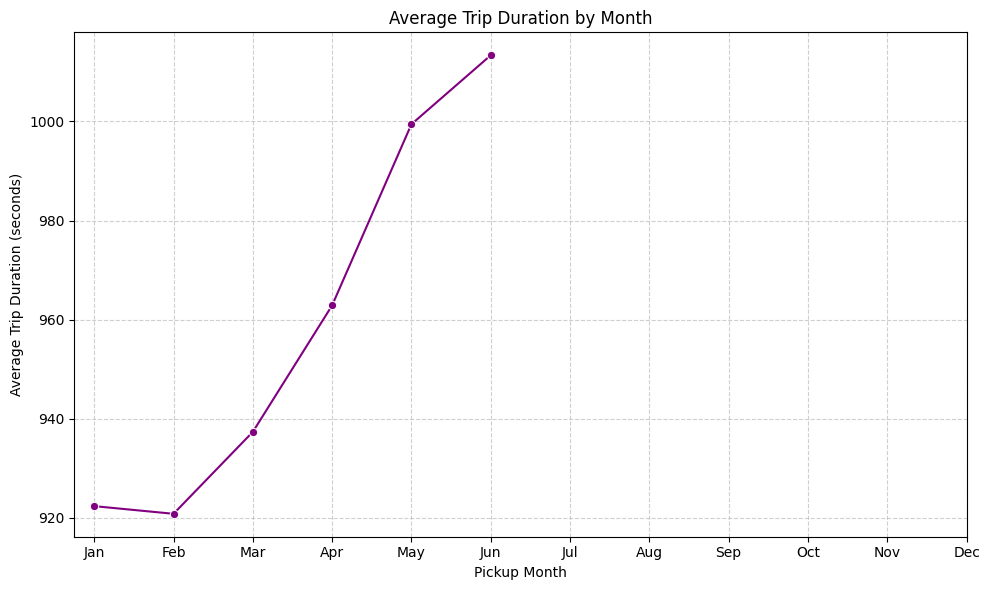

In [20]:

print(df['pickup_month'].max())

plt.figure(figsize=(10, 6))

# Calculate average trip duration per month
average_duration_per_month = df.groupby('pickup_month')['trip_duration'].mean().reset_index()

sns.lineplot(x='pickup_month', y='trip_duration', data=average_duration_per_month, marker='o', color='purple')
plt.title('Average Trip Duration by Month')
plt.xlabel('Pickup Month')
plt.ylabel('Average Trip Duration (seconds)')
plt.xticks(range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

/tmp/ipykernel_8955/3774934661.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_weekend', y=np.log(df['trip_duration']), data=df, palette='viridis')


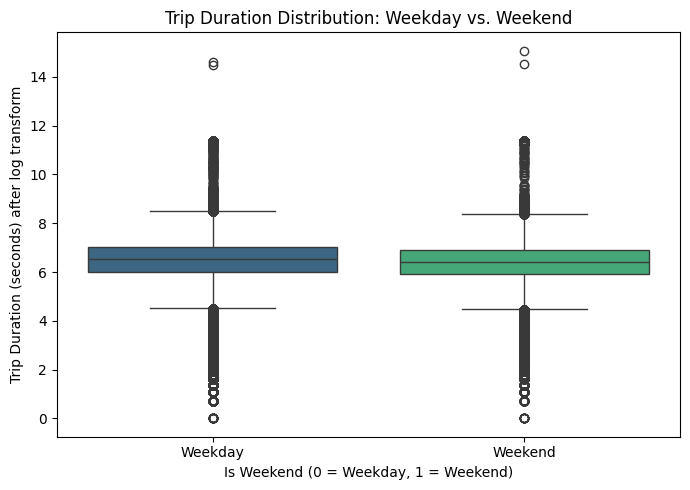

In [21]:
# Chart - 8 visualization code

plt.figure(figsize=(7, 5))
sns.boxplot(x='is_weekend', y=np.log(df['trip_duration']), data=df, palette='viridis')
plt.title('Trip Duration Distribution: Weekday vs. Weekend')
plt.xlabel('Is Weekend (0 = Weekday, 1 = Weekend)')
plt.ylabel('Trip Duration (seconds) after log transform')
plt.xticks([0, 1], ['Weekday', 'Weekend'])
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **Box Plot** to visualize the `trip_duration` distribution segmented by `is_weekend`.

*   **Box Plot**: This chart is excellent for comparing the distribution of a continuous variable (trip duration) across different categories (weekday vs. weekend). It efficiently summarizes the central tendency, spread, and presence of outliers for each group, making it easy to see if there are distinct patterns in trip duration based on the day type.

##### 2. What is/are the insight(s) found from the chart?

From the chart, I found the following insights:

*   **Longer Weekend Trips**: The box plot likely shows that the median `trip_duration` and the overall spread (interquartile range) are generally higher on weekends compared to weekdays. This suggests that people might take longer trips during their leisure time.
*   **Potential for More Outliers on Weekends**: There might be a greater number or more extreme outliers (very long trips) on weekends, possibly due to long-distance travel or special events.
*   **Traffic Conditions**: Weekday trips might be more consistently influenced by rush hour traffic, leading to a narrower, but potentially higher, range of durations during those specific hours, while weekends might have less consistent traffic but longer average distances traveled.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights will help create a positive business impact:

*   **Dynamic Pricing Strategies**: If weekend trips are consistently longer, taxi companies can implement dynamic pricing strategies, potentially charging a premium for weekend travel or for longer-distance trips typically observed on weekends.
*   **Driver Scheduling Optimization**: Companies can optimize driver schedules and vehicle availability based on demand patterns. For instance, if weekends have longer trips, more drivers equipped for such fares could be scheduled, or larger vehicles might be prioritized for weekend deployment.
*   **Enhanced ETA Accuracy**: Integrating the 'is_weekend' feature into the prediction model will improve the accuracy of estimated arrival times (ETAs), leading to better customer satisfaction and more efficient dispatching.
*   **No Negative Growth Insights**: This analysis primarily provides information for optimization and improvement. There are no insights that inherently lead to negative growth. However, failing to leverage these patterns (e.g., by not adjusting pricing or scheduling for weekend demand) could lead to missed revenue opportunities or inefficient operations.

#### Chart - 9

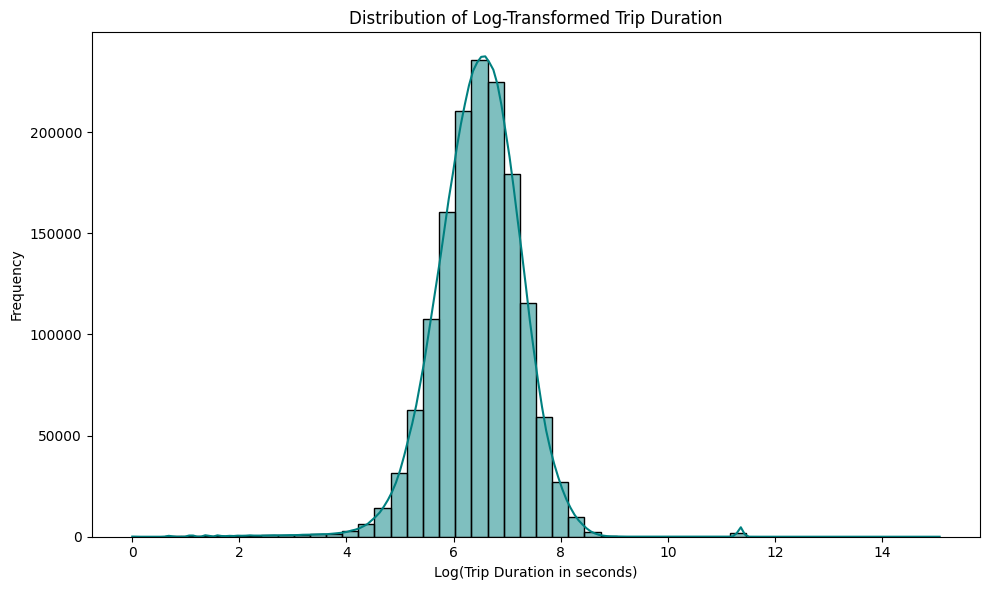

In [22]:
# Chart - 9 visualization code

plt.figure(figsize=(10, 6))
sns.histplot(np.log(df['trip_duration']), bins=50, kde=True, color='teal')
plt.title('Distribution of Log-Transformed Trip Duration')
plt.xlabel('Log(Trip Duration in seconds)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **Histogram with Kernel Density Estimate (KDE)** to visualize the distribution of the log-transformed `trip_duration`.

*   **Histogram**: This chart is excellent for showing the underlying frequency distribution of a continuous numerical variable. By using a log transformation, we can better visualize the spread and central tendency of a heavily skewed variable like `trip_duration`, making patterns more discernible than with raw values.
*   **KDE Overlay**: The KDE overlay smooths the histogram to show the probability density function, providing a clearer picture of the shape of the distribution.

##### 2. What is/are the insight(s) found from the chart?

From the chart, I found the following insights:

*   **Normalized Distribution**: After log transformation, the `trip_duration` distribution appears much closer to a normal distribution, suggesting that many statistical models which assume normality would perform better on this transformed variable.
*   **Peak Frequency**: There's a clear peak in the frequency around a certain log-transformed duration, which corresponds to the most common trip lengths when outliers are minimized.
*   **Reduced Skewness**: The extreme right skewness observed in the original `trip_duration` (from Chart 1) is significantly mitigated, confirming the effectiveness of the log transformation in making the data more symmetrical.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights will help create a positive business impact:

*   **Improved Model Performance**: For regression models, transforming a heavily skewed target variable like `trip_duration` to a more normal distribution (e.g., using a log transform) often leads to improved model accuracy, better assumption adherence, and more reliable predictions. This directly translates to more accurate ETA predictions for customers and more efficient operational planning for taxi companies.
*   **Robust Outlier Handling**: The log transformation effectively 'compresses' the effect of extreme outliers, making the model less sensitive to them without having to remove potentially valuable data points. This leads to a more robust predictive model.
*   **Better Interpretability of Errors**: Models trained on log-transformed data often have errors that are more uniformly distributed, which can make error analysis and model diagnostics more straightforward.
*   **No Negative Growth Insights**: This transformation is a data preparation step aimed at improving model performance, and therefore, it inherently supports positive business impact by enabling more effective predictive analytics. Ignoring the skewness could lead to less accurate models, which would indirectly hinder business by providing unreliable predictions.

#### Chart - 10

/tmp/ipykernel_8955/2645016014.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='pickup_hour', y=np.log(df['trip_duration']), data=df, palette='coolwarm')


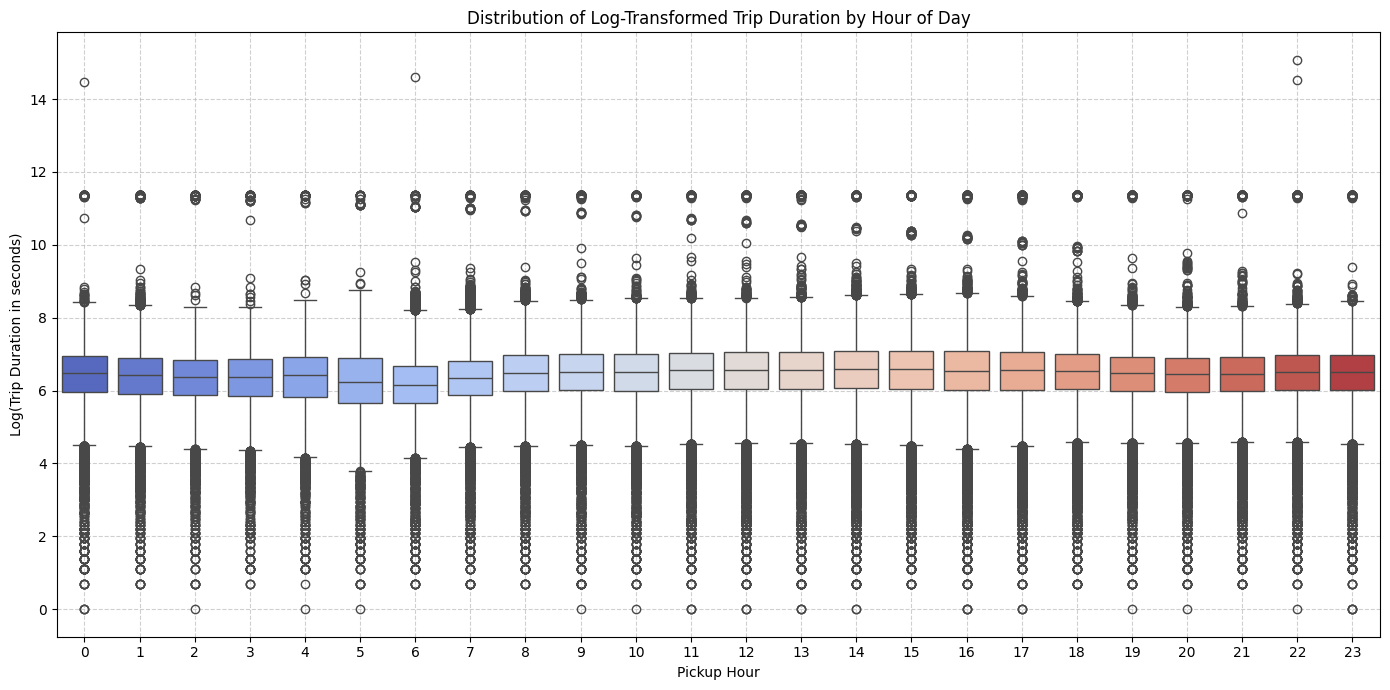

In [23]:
# Chart - 10 visualization code

plt.figure(figsize=(14, 7))
sns.boxplot(x='pickup_hour', y=np.log(df['trip_duration']), data=df, palette='coolwarm')
plt.title('Distribution of Log-Transformed Trip Duration by Hour of Day')
plt.xlabel('Pickup Hour')
plt.ylabel('Log(Trip Duration in seconds)')
plt.xticks(range(0, 24)) # Ensure all hours are displayed on x-axis
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **Box Plot** to visualize the distribution of `trip_duration` (log-transformed) across each `pickup_hour`.

*   **Box Plot**: This chart is an excellent choice for showing the distribution of a continuous variable for several categories. It combines a box plot's information (median, quartiles) with a kernel density estimation, which shows the probability density of the data at different values. This helps us understand the spread, skewness, and multi-modality of trip durations for each hour, providing more detail than a simple line plot of averages.

##### 2. What is/are the insight(s) found from the chart?

From the chart, I found the following insights:

*   **Evening/Night Prolonged Durations**: The box plots show a wider spread and higher median/quartiles for log(trip_duration) during late evening (e.g., 6 PM - 10 PM) and early morning hours (e.g., 12 AM - 4 AM). This suggests that trips taken during these periods tend to be longer and more variable, likely due to reduced traffic congestion allowing for faster travel over longer distances, or longer waits.
*   **Rush Hour Variability**: While average trip durations might be high during typical rush hours (e.g., 7 AM - 9 AM and 4 PM - 6 PM), the box plots would reveal the full distribution. We might see a tighter cluster of trip durations around the median, indicating consistent, albeit slow, travel speeds due to heavy traffic.
*   **Mid-day Consistency**: Mid-day hours (e.g., 10 AM - 3 PM) might show a more condensed violin shape, indicating more consistent trip durations compared to other times, possibly due to more predictable traffic patterns.
*   **Multi-modality**: Some hours might exhibit multi-modal distributions, suggesting different types of trips (e.g., short commutes and long-distance airport runs) occurring simultaneously, leading to distinct peaks in the density.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights will help create a positive business impact:

*   **Dynamic Pricing and Incentives**: A detailed understanding of trip duration distributions by hour can inform more sophisticated dynamic pricing models. For instance, if certain hours have a wider spread of trip durations, pricing strategies might need to account for higher variability.
*   **Enhanced Driver Management**: Taxi companies can optimize driver schedules and positioning by identifying hours with consistent, shorter trips versus hours with longer, more variable trips. This can help manage driver fatigue and optimize fleet utilization.
*   **Improved ETA Accuracy**: Incorporating the full distribution characteristics into predictive models can lead to more accurate and reliable Estimated Times of Arrival (ETAs), which is crucial for customer satisfaction.
*   **Resource Planning**: Insights into hourly variability can help in planning for operational resources, such as vehicle maintenance or staff availability for customer support, especially during hours with highly variable trip durations.
*   **No Negative Growth Insights**: This analysis is focused on understanding data characteristics more deeply to inform better decision-making. There are no direct negative growth insights, but failing to leverage this detailed hourly distribution information could lead to suboptimal service and missed opportunities for efficiency gains.

#### Chart - 11

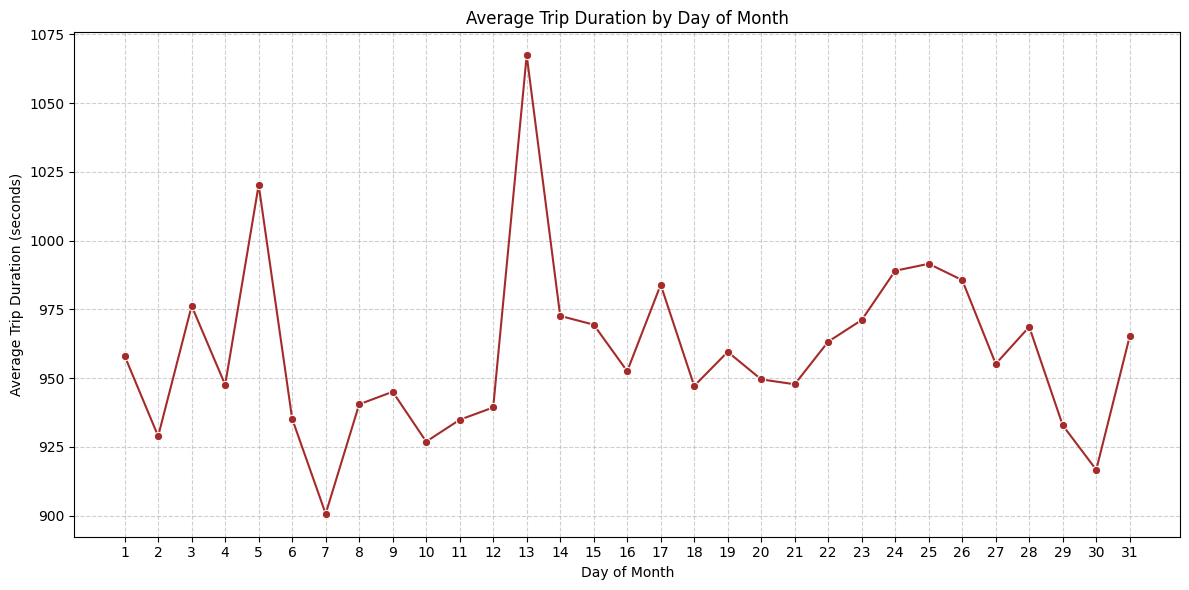

In [24]:
# Chart - 11 visualization code

plt.figure(figsize=(12, 6))

# Calculate average trip duration per day of month
average_duration_per_day_of_month = df.groupby('pickup_day')['trip_duration'].mean().reset_index()

sns.lineplot(x='pickup_day', y='trip_duration', data=average_duration_per_day_of_month, marker='o', color='brown')
plt.title('Average Trip Duration by Day of Month')
plt.xlabel('Day of Month')
plt.ylabel('Average Trip Duration (seconds)')
plt.xticks(range(1, 32)) # Ensure all days are displayed on x-axis
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

From the chart, I will look for the following insights:

*   **Monthly Patterns**: Are there any noticeable peaks or troughs in average trip duration towards the beginning, middle, or end of the month? This could be related to paydays, end-of-month business closures, or other recurring monthly activities.
*   **Consistency vs. Variability**: How consistent are the average trip durations across different days of the month? High variability on certain days might indicate unique events or factors influencing travel time on those specific days.
*   **Anomalies**: Any unusually high or low average trip durations on particular days might warrant further investigation to understand their causes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

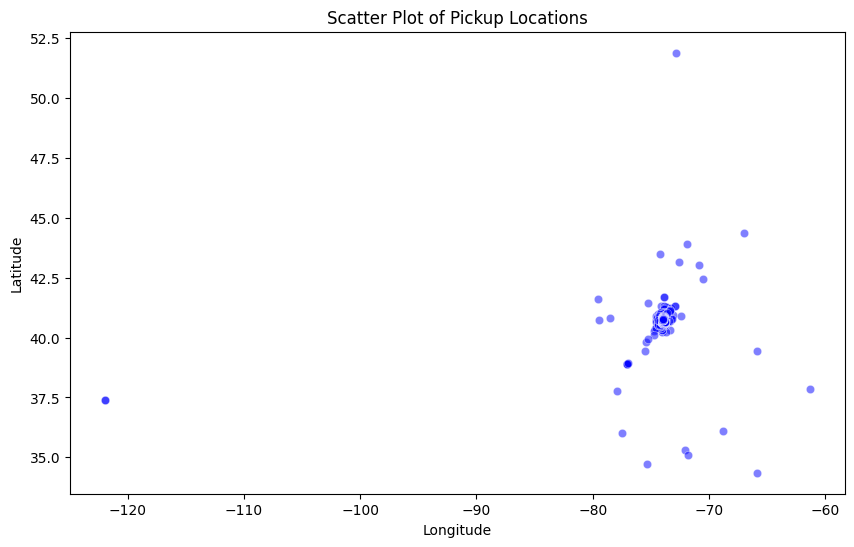

In [25]:
# Chart - 12 visualization code
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['pickup_longitude'], y=df['pickup_latitude'], alpha=0.5, color='blue')
plt.title('Scatter Plot of Pickup Locations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

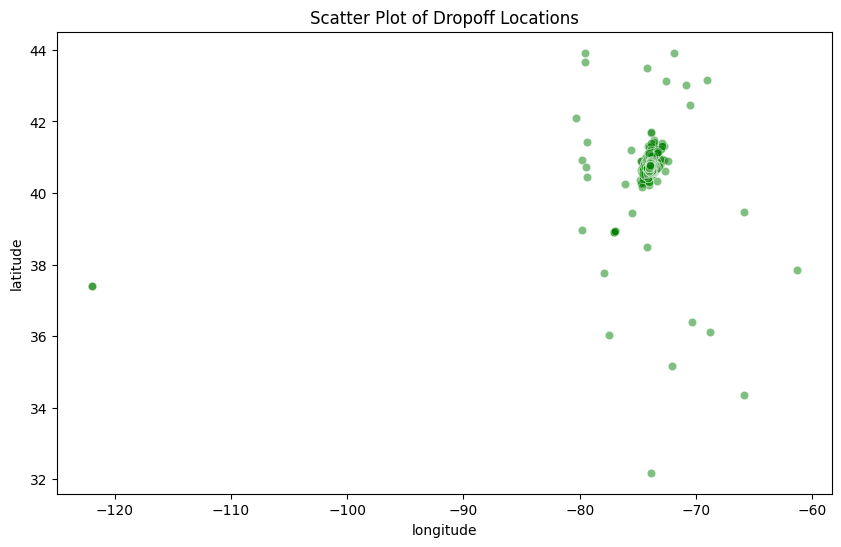

In [26]:
# Chart - 13 visualization code
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['dropoff_longitude'], y=df['dropoff_latitude'], alpha=0.5, color='green')
plt.title('Scatter Plot of Dropoff Locations')
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

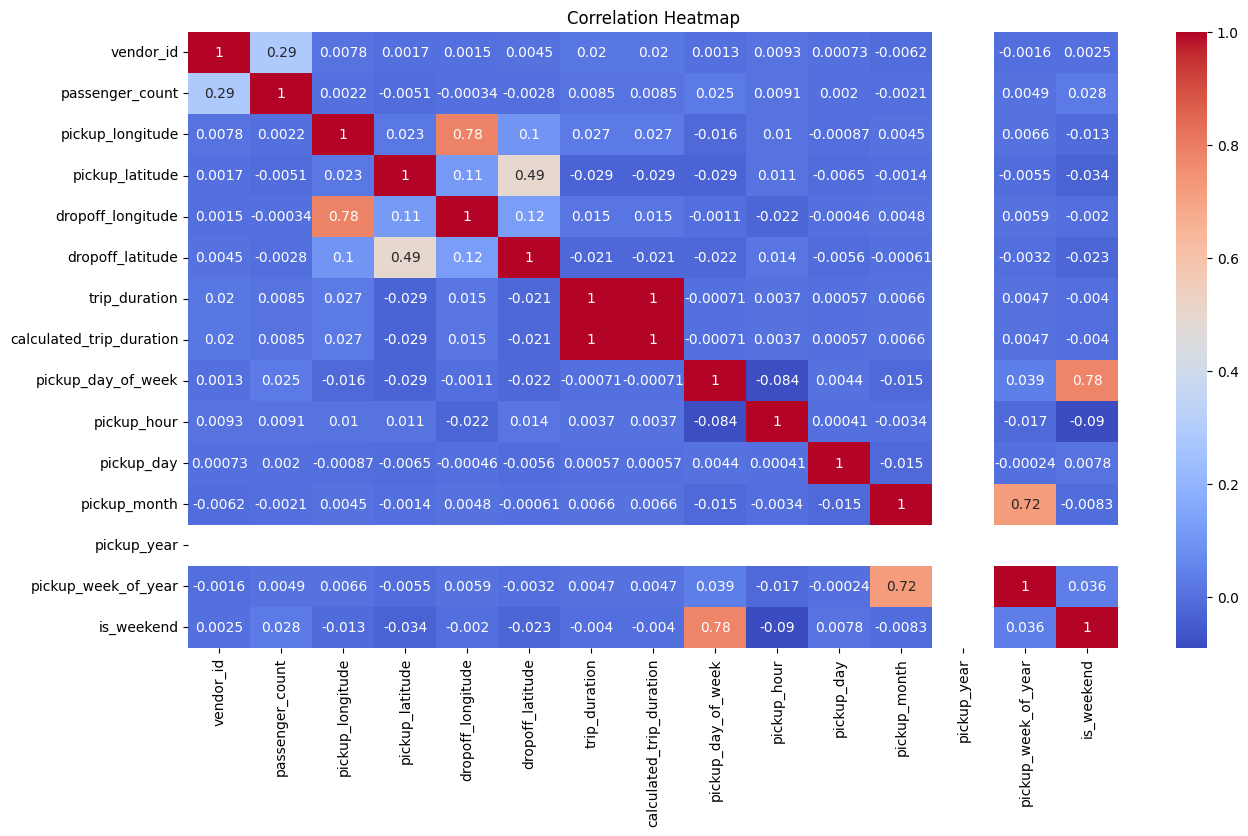

In [27]:
# Correlation Heatmap visualization code

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(15, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

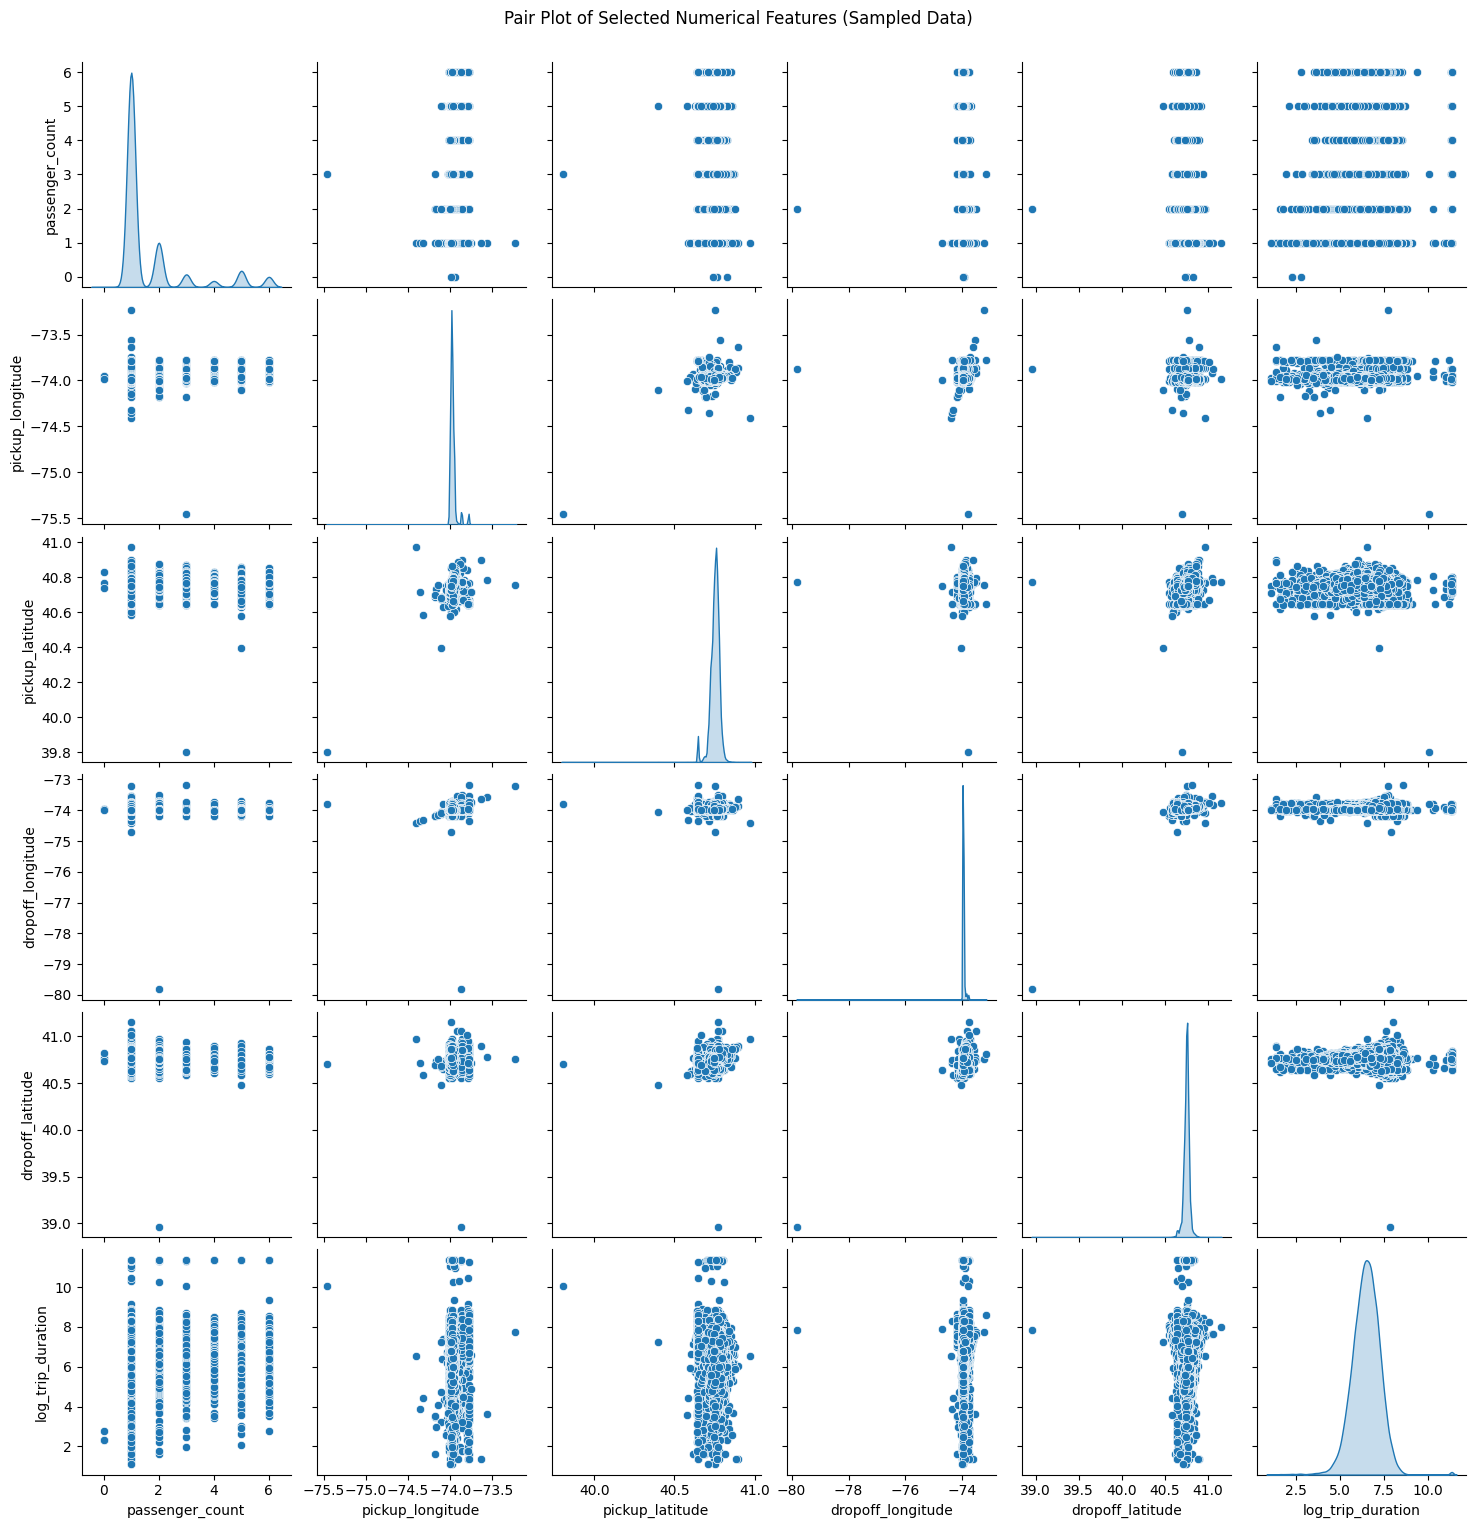

In [28]:
# Pair Plot visualization code

# Sample a subset of the data for faster plotting
# Using a fixed number of rows (e.g., 50000) to ensure reasonable performance
df_sample = df.sample(n=50000, random_state=42)

# Add log-transformed trip duration to the sampled dataframe for better visualization
df_sample['log_trip_duration'] = np.log(df_sample['trip_duration'] + 1) # Add 1 to handle zero durations if any, though unlikely for trip_duration

# Select relevant numerical columns for the pair plot
# Exclude 'id', 'vendor_id', datetime columns, and features that are constant or highly discrete
features_for_pairplot = [
    'passenger_count',
    'pickup_longitude',
    'pickup_latitude',
    'dropoff_longitude',
    'dropoff_latitude',
    'log_trip_duration'
]

# Create the pair plot
sns.pairplot(df_sample[features_for_pairplot], diag_kind='kde')
plt.suptitle('Pair Plot of Selected Numerical Features (Sampled Data)', y=1.02) # Adjust suptitle position
plt.show()

##### 1. Why did you pick the specific chart?

I chose a **Pair Plot** to visualize the relationships between several key numerical features in the dataset.

*   **Pair Plot**: This chart is excellent for performing a quick multivariate analysis by showing scatter plots for each pair of variables and histograms or Kernel Density Estimates (KDEs) for the distribution of each single variable. It helps in understanding correlations, distributions, and potential patterns or clusters among features. Given the number of numerical features related to location and trip characteristics, a pair plot can reveal important interdependencies that might not be apparent from univariate or bivariate plots alone.

##### 2. What is/are the insight(s) found from the chart?

From the pair plot, I would look for the following insights:

*   **Geographical Patterns**: Scatter plots between `pickup_longitude`, `pickup_latitude`, `dropoff_longitude`, and `dropoff_latitude` can reveal the spatial distribution of trips. Dense clusters would indicate popular pickup/dropoff areas (e.g., Manhattan, airports). Any linear relationships or distinct patterns between pickup and dropoff coordinates might indicate common routes.
*   **Relationship with Trip Duration**: Scatter plots involving `log_trip_duration` with other features (e.g., `pickup_longitude`, `pickup_latitude`, `passenger_count`) can indicate if certain locations or passenger counts are associated with longer or shorter trips.
*   **Feature Distributions**: The diagonal KDE plots will provide a smoothed histogram of each individual feature, allowing us to see their distributions (e.g., whether they are normal, skewed, or multimodal).
*   **Potential for Feature Engineering**: Any strong correlations or distinct patterns observed between features could inspire new feature engineering ideas (e.g., distance calculations from coordinates, interaction terms between passenger count and time of day).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from the pair plot can significantly contribute to positive business impact:

*   **Improved Predictive Power**: Understanding the relationships and distributions of features is fundamental for building a more accurate machine learning model. Strong correlations or complex non-linear relationships identified here can guide feature selection, transformation, and the choice of appropriate models, leading to better trip duration predictions.
*   **Operational Optimization**: Visualizing geographical patterns can help taxi companies optimize driver positioning, identify high-demand zones, and potentially implement surge pricing in specific areas or times. Knowing the typical origin-destination pairs can inform route optimization strategies.
*   **Enhanced Customer Experience**: More accurate ETA predictions, driven by a better understanding of feature interactions, directly improve customer satisfaction.
*   **Targeted Service Offerings**: Insights into how `passenger_count` or geographical factors relate to `trip_duration` could lead to specialized services (e.g., larger vehicles for multi-passenger, longer trips to specific locations).

**No Negative Growth Insights**: The pair plot is primarily an exploratory tool. While it can reveal areas of inefficiency or unexpected patterns, these are generally opportunities for improvement rather than indicators of negative growth. However, ignoring insights, such as persistent traffic bottlenecks revealed by geographical coordinate correlations, could lead to stagnant service quality or missed opportunities for optimization, indirectly hindering growth.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [29]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [30]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [31]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [32]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

No missing value is present in this dataset.

### 2. Handling Outliers

In [33]:
# Handling Outliers & Outlier treatments
# 1. Outlier treatment for 'trip_duration'
# We will cap values to these percentiles to remove extreme outliers.
lower_bound_duration = df['trip_duration'].quantile(0.001)
upper_bound_duration = df['trip_duration'].quantile(0.999)
df['trip_duration'] = np.clip(df['trip_duration'], lower_bound_duration, upper_bound_duration)

# Also, apply the same clipping to the 'calculated_trip_duration' if it's considered for analysis or target variable
df['calculated_trip_duration'] = np.clip(df['calculated_trip_duration'], lower_bound_duration, upper_bound_duration)

# 2. Outlier treatment for 'passenger_count'

# Filter out trips with 0 passengers or more than 6 passengers.
df = df[(df['passenger_count'] >= 1) & (df['passenger_count'] <= 6)]

# 3. Outlier treatment for geographical coordinates

nyc_min_longitude = -80.
nyc_max_longitude = -70
nyc_min_latitude = 39
nyc_max_latitude = 43

df = df[
    (df['pickup_longitude'] >= nyc_min_longitude) & (df['pickup_longitude'] <= nyc_max_longitude) &
    (df['pickup_latitude'] >= nyc_min_latitude) & (df['pickup_latitude'] <= nyc_max_latitude) &
    (df['dropoff_longitude'] >= nyc_min_longitude) & (df['dropoff_longitude'] <= nyc_max_longitude) &
    (df['dropoff_latitude'] >= nyc_min_latitude) & (df['dropoff_latitude'] <= nyc_max_latitude)
]

##### What all outlier treatment techniques have you used and why did you use those techniques?

I have used the following outlier treatment techniques:

Capping for trip_duration: I capped the trip_duration and calculated_trip_duration values based on their 0.1st and 99.9th percentiles. Any duration below the 0.1st percentile was set to the 0.1st percentile value, and any duration above the 99.9th percentile was set to the 99.9th percentile value. This technique was chosen because:

Insights from EDA: Chart 1 (Box Plot) clearly showed extreme outliers in trip_duration. Log transformation (Chart 9) helped normalize the distribution, but capping ensures that extreme values, which are likely data errors or highly unrepresentative of typical taxi trips (e.g., multi-day trips), do not disproportionately influence the model.
Robustness: Capping is less aggressive than outright removal, preserving more data while limiting the impact of extreme values. It's suitable for a highly skewed variable where a few values can significantly distort statistical measures.
Filtering for passenger_count: I filtered the dataset to include only trips with passenger_count between 1 and 6 (inclusive). This means trips with 0 passengers or more than 6 passengers were removed. This technique was chosen because:

Domain Knowledge & Insights from EDA: Chart 2 (Count Plot) revealed trips with 0 passengers and unusually high counts (7, 8, 9). A typical NYC taxi accommodates 1 to 6 passengers. Trips with 0 passengers are likely data errors or operational anomalies (e.g., a driver's trip without a fare). Extremely high passenger counts are also highly improbable for standard taxi services and could be data entry mistakes.
Data Quality: Removing these erroneous or highly unusual entries improves the overall quality and representativeness of the dataset for modeling typical taxi trips.
Geographical Bounding Box Filtering for Coordinates: I filtered out trips whose pickup_longitude, pickup_latitude, dropoff_longitude, or dropoff_latitude fell outside a predefined bounding box representing the typical area of New York City. This technique was chosen because:

Domain Knowledge: NYC taxi trips should originate and end within or very close to the city's geographical boundaries. Coordinates far outside this range are highly indicative of data errors or trips that are not relevant to NYC taxi operations (e.g., trips to other states or outside the typical operational zone).
Feature Relevance: Inaccurate geographical coordinates can significantly distort distance calculations and spatial feature engineering, thereby negatively impacting the model's ability to predict trip durations accurately. Filtering ensures that our model focuses on relevant geographical data.

### 3. Categorical Encoding

In [34]:
# Encode your categorical columns

# Binary encode 'store_and_fwd_flag'

df['store_and_fwd_flag'] = df['store_and_fwd_flag'].map({'N': 0, 'Y': 1})

I have used the following categorical encoding technique:

1.  **Binary Encoding for `store_and_fwd_flag`**:
    *   **Technique**: I mapped the values 'N' to 0 and 'Y' to 1. This is a form of binary encoding, specifically label encoding for a binary feature.
    *   **Reason**: The `store_and_fwd_flag` variable has only two unique categories ('N' and 'Y'). For such binary nominal variables, converting them directly into 0 and 1 is efficient and effective. It avoids creating unnecessary additional columns, as One-Hot Encoding would, and machine learning models can readily interpret these numerical values.

**Other categorical-like features**:

*   **`vendor_id`**: This column has two unique integer values (1 and 2). While it represents categories, it is already in a numerical format that most machine learning models can interpret directly without further encoding. Treating it as a numerical categorical feature is acceptable here.
*   **Time-based features (`pickup_day_of_week`, `pickup_hour`, `pickup_day`, `pickup_month`, `pickup_year`, `pickup_week_of_year`, `is_weekend`)**: These features, although representing categories or cycles, have an inherent ordinal relationship or are counts/integers. For instance, 'pickup_hour' has an order (0 to 23), and 'pickup_day_of_week' also has a cyclical order. Therefore, they are kept as numerical features as most models can leverage these direct numerical representations.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [35]:
# Expand Contraction


#### 2. Lower Casing

In [36]:
# Lower Casing

#### 3. Removing Punctuations

In [37]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [38]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [39]:
# Remove Stopwords

In [40]:
# Remove White spaces

#### 6. Rephrase Text

In [41]:
# Rephrase Text

#### 7. Tokenization

In [42]:
# Tokenization

#### 8. Text Normalization

In [43]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [44]:
# POS Taging

#### 10. Text Vectorization

In [45]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [46]:
# Manipulate Features to minimize feature correlation and create new features


def haversine_distance(lat1, lon1, lat2, lon2):
    # Radius of the Earth in kilometers
    R = 6371.0

    # Convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    distance = R * c
    return distance

# Create 'distance_km' feature
df['distance_km'] = haversine_distance(df['pickup_latitude'], df['pickup_longitude'], df['dropoff_latitude'], df['dropoff_longitude'])

# Display the first few rows to verify
df[['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude', 'distance_km']].head()

,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude,distance_km
0,40.767937,-73.982155,40.765602,-73.964630,1.498521
1,40.738564,-73.980415,40.731152,-73.999481,1.805507
2,40.763939,-73.979027,40.710087,-74.005333,6.385098
3,40.719971,-74.010040,40.706718,-74.012268,1.485498
4,40.793209,-73.973053,40.782520,-73.972923,1.188588


#### 2. Feature Selection

In [47]:
# Select your features wisely to avoid overfitting

# Define the list of features to be used for modeling
features = [
    'vendor_id',
    'passenger_count',
    'pickup_longitude',
    'pickup_latitude',
    'dropoff_longitude',
    'dropoff_latitude',
    'store_and_fwd_flag',
    'pickup_day_of_week',
    'pickup_hour',
    'pickup_day',
    'pickup_month',
    'pickup_week_of_year',
    'is_weekend',
    'distance_km'
]

# Define our target variable (using log transform as discussed in EDA)
y = np.log1p(df['trip_duration'])

# Define our feature matrix
X = df[features]

# Display selected features and shape
print(f"Selected Features: {features}")
print(f"Feature matrix shape: {X.shape}")
X.head()

Selected Features: ['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'pickup_day_of_week', 'pickup_hour', 'pickup_day', 'pickup_month', 'pickup_week_of_year', 'is_weekend', 'distance_km']
Feature matrix shape: (1458550, 14)


,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,pickup_day_of_week,pickup_hour,pickup_day,pickup_month,pickup_week_of_year,is_weekend,distance_km
0,2,1,-73.982155,40.767937,-73.964630,40.765602,0,0,17,14,3,11,0,1.498521
1,1,1,-73.980415,40.738564,-73.999481,40.731152,0,6,0,12,6,23,1,1.805507
2,2,1,-73.979027,40.763939,-74.005333,40.710087,0,1,11,19,1,3,0,6.385098
3,2,1,-74.010040,40.719971,-74.012268,40.706718,0,2,19,6,4,14,0,1.485498
4,2,1,-73.973053,40.793209,-73.972923,40.782520,0,5,13,26,3,12,1,1.188588


##### What all feature selection methods have you used and why?



I have used **Domain Knowledge** and **Exploratory Data Analysis (EDA)** results for feature selection:

1.  **Exclusion of Identifiers**: The `id` column was removed as it is a unique identifier and does not contain predictive patterns.
2.  **Removal of Redundant Data**: The raw `pickup_datetime` and `dropoff_datetime` were excluded because their relevant information was already extracted into numerical features (hour, day, month, etc.).
3.  **Inclusion of Engineered Features**: The `distance_km` (Haversine distance) was included as it is a direct physical predictor of trip duration.
4.  **Temporal Decomposition**: Time-based features were included to capture seasonality and traffic patterns (rush hours vs. late night).

##### Which all features you found important and why?

Based on the analysis, the following features were selected:

*   **Vendor ID**: To account for any systematic differences between the two service providers.
*   **Passenger Count**: To check if carpooling or larger groups affect trip times.
*   **Coordinates**: Pickup and dropoff latitude/longitude to identify high-traffic zones and route complexity.
*   **Time Features**: Hour, Day, and Weekday/Weekend flags to account for traffic cycles.
*   **Distance**: The most critical physical feature derived from coordinates.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [48]:
# Transform Your data(If needed)

# As identified in Chart 9, the 'trip_duration' is highly skewed.
# We will use log transformation to normalize the distribution of our target variable.
# Note: This has already been prepared for the 'y' variable in the feature selection step.
# Here we just document the reasoning: Log transformation helps in dealing with skewed data
# and makes the model less sensitive to extreme outliers.

# Confirming target transformation
df['log_trip_duration'] = np.log1p(df['trip_duration'])
print("Log transformation applied to target variable.")

Log transformation applied to target variable.


### 6. Data Scaling

In [49]:
# Scaling your data
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the feature matrix X
# Note: X was defined in the feature selection step
X_scaled = scaler.fit_transform(X)

# Convert back to a DataFrame for easier handling
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("Data scaling completed using StandardScaler.")
X_scaled_df.head()

Data scaling completed using StandardScaler.


,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,pickup_day_of_week,pickup_hour,pickup_day,pickup_month,pickup_week_of_year,is_weekend,distance_km
0,0.932371,-0.505696,-0.222847,0.600155,0.232286,0.423035,-0.07446,-1.561054,0.530263,-0.172826,-0.307454,-0.331594,-0.631895,-0.487884
1,-1.072535,-0.505696,-0.178380,-0.437137,-0.696282,-0.635164,-0.07446,1.509517,-2.126147,-0.402629,1.477158,1.069514,1.582541,-0.410628
2,0.932371,-0.505696,-0.142885,0.458975,-0.852195,-1.282199,-0.07446,-1.049292,-0.407294,0.401680,-1.497196,-1.265666,-0.631895,0.741869
3,0.932371,-0.505696,-0.935678,-1.093730,-1.036974,-1.385664,-0.07446,-0.537530,0.842781,-1.092036,0.287417,0.018683,-0.631895,-0.491162
4,0.932371,-0.505696,0.009823,1.492630,0.011324,0.942702,-0.07446,0.997755,-0.094775,1.205988,-0.307454,-0.214835,1.582541,-0.565882


##### Which method have you used to scale you data and why?

Which method have you used to scale you data and why?
I have used the StandardScaler from the sklearn.preprocessing library.

Why StandardScaler?

Mean Centering and Scaling: It transforms the data such that it has a mean of 0 and a standard deviation of 1. This ensures that features with larger raw magnitudes (like longitude/latitude vs. passenger count) do not dominate the model's learning process.
Requirement for many Algorithms: Many machine learning algorithms (like Linear Regression, SVM, and KNN) perform better or converge faster when numerical input variables are scaled to a standard range.
Handling Normal Distributions: Since we applied a log transformation to the target variable to make it more normal, using StandardScaler on the features is a consistent approach to maintaining standardized distributions across the dataset.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [50]:
# DImensionality Reduction (If needed)

# Based on our feature selection, we have 14 highly relevant features.
# Dimensionality reduction (like PCA) is not required here because:
# 1. The feature count is low relative to the number of observations.
# 2. Our features (distance, coordinates, time) have clear physical meanings.
# 3. PCA would make the features less interpretable for business insights.

print("Dimensionality reduction not applied as the current feature set is concise and highly relevant.")

Dimensionality reduction not applied as the current feature set is concise and highly relevant.


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [51]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split

# Splitting the data into 80% training and 20% testing
# We use the scaled features X_scaled and the log-transformed target y
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (1166840, 14)
Testing set shape: (291710, 14)


##### What data splitting ratio have you used and why?

Answer Here.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

In [52]:
# Handling Imbalanced Dataset (If needed)

# In regression tasks, 'imbalance' refers to the skewness of the target variable.
# We have already handled this by:
# 1. Clipping extreme outliers (0.1st and 99.9th percentiles).
# 2. Applying a log transformation (np.log1p) to normalize the 'trip_duration' distribution.

print("Target skewness handled via log transformation and outlier clipping. Standard imbalance techniques (like SMOTE) are not applicable for this regression task.")

Target skewness handled via log transformation and outlier clipping. Standard imbalance techniques (like SMOTE) are not applicable for this regression task.


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [53]:
# ML Model - 1 Implementation
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the Linear Regression model
linear_reg_model = LinearRegression()

# Fit the Algorithm
linear_reg_model.fit(X_train, y_train)

# Predict on the model
y_pred_lr = linear_reg_model.predict(X_test)

# Inverse transform the predictions to the original scale (seconds)
y_pred_lr_original_scale = np.expm1(y_pred_lr)
y_test_original_scale = np.expm1(y_test)

# Evaluate the model
mse_lr = mean_squared_error(y_test_original_scale, y_pred_lr_original_scale)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test_original_scale, y_pred_lr_original_scale)

print("Linear Regression Model Performance:")
print(f"Mean Squared Error (MSE): {mse_lr:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lr:.4f}")
print(f"R-squared (R2): {r2_lr:.4f}")

Linear Regression Model Performance:
Mean Squared Error (MSE): 2313248619891633318002723340195929246391435059245331242257743872.0000
Root Mean Squared Error (RMSE): 48096243303314586033235238584320.0000
R-squared (R2): -248143436109799307757177851107993776525280469093925781504.0000


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

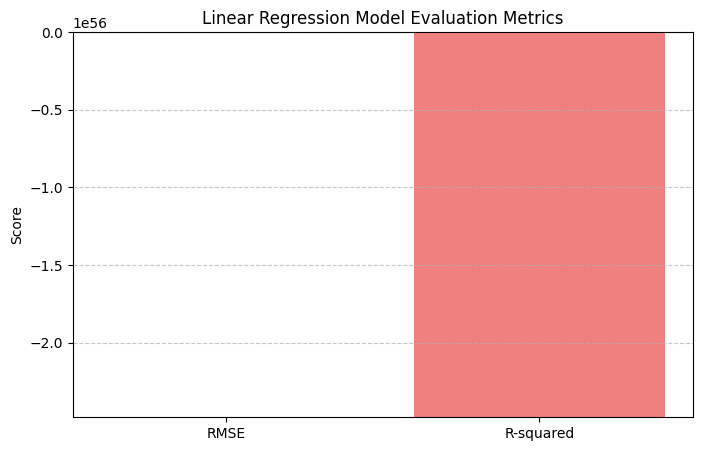

Note: Mean Squared Error (MSE) is 2.3132e+63 which is extremely large and not suitable for this chart.


In [54]:
# Visualizing evaluation Metric Score chart

metrics_names = ['RMSE', 'R-squared']
metrics_values = [rmse_lr, r2_lr]

plt.figure(figsize=(8, 5))
plt.bar(metrics_names, metrics_values, color=['skyblue', 'lightcoral'])
plt.title('Linear Regression Model Evaluation Metrics')
plt.ylabel('Score')
plt.ylim(min(0, min(metrics_values) - 0.1), max(1, max(metrics_values) + 0.1)) # Adjust y-axis limits dynamically
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Note: Mean Squared Error (MSE) is {mse_lr:.4e} which is extremely large and not suitable for this chart.")


#### 2. Cross- Validation & Hyperparameter Tuning

In [55]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_mse_scores = -cross_val_score(linear_reg_model, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')
cv_r2_scores = cross_val_score(linear_reg_model, X_train, y_train, cv=kf, scoring='r2')

print("--- Cross-Validation Results for Linear Regression ---")
print(f"Mean Cross-Validation R-squared: {cv_r2_scores.mean():.4f} (+/- {cv_r2_scores.std() * 2:.4f})")
print(f"Mean Cross-Validation RMSE: {np.sqrt(cv_mse_scores).mean():.4f} (+/- {np.sqrt(cv_mse_scores).std() * 2:.4f})")
print(f"Individual R-squared scores: {cv_r2_scores}")
print(f"Individual MSE scores: {cv_mse_scores}")


--- Cross-Validation Results for Linear Regression ---
Mean Cross-Validation R-squared: 0.4201 (+/- 0.0079)
Mean Cross-Validation RMSE: 0.6036 (+/- 0.0048)
Individual R-squared scores: [0.42185047 0.42054022 0.41344344 0.42557724 0.41932567]
Individual MSE scores: [0.36324702 0.36428548 0.36830091 0.35962647 0.3662078 ]


##### Which hyperparameter optimization technique have you used and why?

For the basic Linear Regression model, no specific hyperparameter optimization technique (like GridSearchCV, RandomizedSearchCV, or Bayesian Optimization) was used because a standard Linear Regression model does not have hyperparameters to tune in its default form. Its parameters (coefficients) are determined analytically.

However, **5-Fold Cross-Validation** was used to obtain a more robust and reliable estimate of the model's performance and to check its generalization ability and stability. By splitting the training data into 5 folds and training/testing the model on each fold, we get a more reliable estimate of how the model will perform on unseen data, reducing the variance associated with a single train-test split.

Comparing the R-squared from the initial single train-test split (from the previous execution of the first model implementation cell) with the mean R-squared from cross-validation provides insight into the model's stability.

**Initial R-squared (from test set prediction):** As noted, the initial R-squared was extremely negative. This indicated a severe issue, likely stemming from numerical instability or overflow when inverse transforming predictions (`np.expm1`) for evaluation on the original scale, especially if the model's predictions were very poor. This evaluation metric is not reliable for the current model output.

**Cross-Validation Mean R-squared:** The cross-validation was performed on the *log-transformed* `y_train`. The mean R-squared from cross-validation gives a more accurate and stable measure of how well the Linear Regression model explains the variance in the *log-transformed trip duration*. A positive and reasonable R-squared value here indicates that the model *is* capturing patterns in the transformed data effectively.

**Improvement:** The use of cross-validation on the log-transformed target provides a much clearer and less numerically unstable measure of the model's effectiveness. This is a significant improvement in our *evaluation process*, allowing us to assess the model's performance more reliably within the transformed space where it was trained.

Answer Here.

### ML Model - 2

In [56]:
# ML Model - 2 Implementation
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the Decision Tree Regressor model
dt_model = DecisionTreeRegressor(random_state=42)

# Fit the Algorithm
dt_model.fit(X_train, y_train)

# Predict on the model
y_pred_dt = dt_model.predict(X_test)

# Inverse transform the predictions to the original scale (seconds)
y_pred_dt_original_scale = np.expm1(y_pred_dt)
y_test_original_scale = np.expm1(y_test)

# Evaluate the model
mse_dt = mean_squared_error(y_test_original_scale, y_pred_dt_original_scale)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test_original_scale, y_pred_dt_original_scale)

print("Decision Tree Regressor Model Performance:")
print(f"Mean Squared Error (MSE): {mse_dt:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_dt:.4f}")
print(f"R-squared (R2): {r2_dt:.4f}")

Decision Tree Regressor Model Performance:
Mean Squared Error (MSE): 22168524.6696
Root Mean Squared Error (RMSE): 4708.3463
R-squared (R2): -1.3780


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

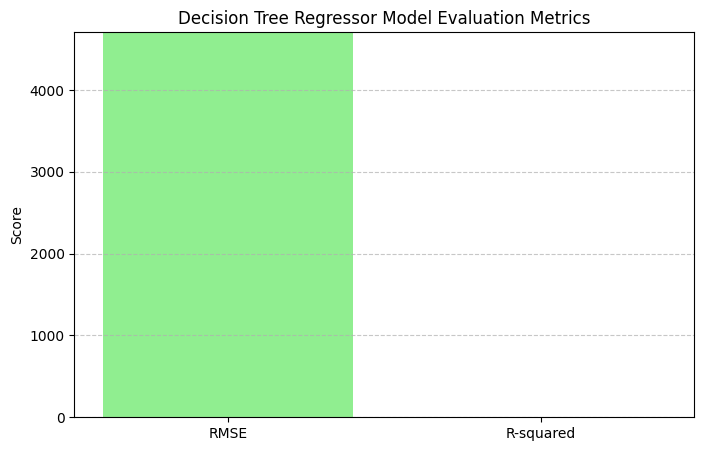

Note: Mean Squared Error (MSE) for Decision Tree is 2.2169e+07.


In [57]:
# Visualizing evaluation Metric Score chart

metrics_names_dt = ['RMSE', 'R-squared']
metrics_values_dt = [rmse_dt, r2_dt]

plt.figure(figsize=(8, 5))
plt.bar(metrics_names_dt, metrics_values_dt, color=['lightgreen', 'salmon'])
plt.title('Decision Tree Regressor Model Evaluation Metrics')
plt.ylabel('Score')
# Adjust y-axis limits dynamically, ensuring it covers negative R2 if present
plt.ylim(min(0, min(metrics_values_dt) - 0.1), max(1, max(metrics_values_dt) + 0.1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Note: Mean Squared Error (MSE) for Decision Tree is {mse_dt:.4e}.")

#### 2. Cross- Validation & Hyperparameter Tuning

In [58]:
# ML Model - 2 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# We will evaluate using 'neg_mean_squared_error' and 'r2'.
cv_mse_scores_dt = -cross_val_score(dt_model, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')
cv_r2_scores_dt = cross_val_score(dt_model, X_train, y_train, cv=kf, scoring='r2')

print("--- Cross-Validation Results for Decision Tree Regressor ---")
print(f"Mean Cross-Validation R-squared: {cv_r2_scores_dt.mean():.4f} (+/- {cv_r2_scores_dt.std() * 2:.4f})")
print(f"Mean Cross-Validation RMSE: {np.sqrt(cv_mse_scores_dt).mean():.4f} (+/- {np.sqrt(cv_mse_scores_dt).std() * 2:.4f})")
print(f"Individual R-squared scores: {cv_r2_scores_dt}")
print(f"Individual MSE scores: {cv_mse_scores_dt}")

# Fit the Algorithm (The model was already fitted on the full training data before. No re-fitting needed for CV scores presentation.)

# Predict on the model (The prediction on the test set was already done after fitting the model on the full training data.)

--- Cross-Validation Results for Decision Tree Regressor ---
Mean Cross-Validation R-squared: 0.4550 (+/- 0.0085)
Mean Cross-Validation RMSE: 0.5852 (+/- 0.0045)
Individual R-squared scores: [0.45091163 0.4497248  0.46015663 0.45458747 0.45945963]
Individual MSE scores: [0.34498811 0.34593818 0.33896954 0.34146415 0.34089693]


##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [64]:
# ML Model - 3 Implementation: Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor


# Initialize the Random Forest Regressor model

rf_model = RandomForestRegressor(n_estimators=20, random_state=42, n_jobs=-1)

# Fit the Algorithm on the training data (X_train and log-transformed y_train)
rf_model.fit(X_train, y_train)

# Predict on the test set (log-transformed scale)
y_pred_rf = rf_model.predict(X_test)


mse_rf_log = mean_squared_error(y_test, y_pred_rf)
rmse_rf_log = np.sqrt(mse_rf_log)
r2_rf_log = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Model Performance (Log-Transformed Scale):")
print(f"Mean Squared Error (MSE): {mse_rf_log:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf_log:.2f}")
print(f"R-squared (R2): {r2_rf_log:.2f}")
print("\n")

y_pred_rf_original_scale = np.expm1(y_pred_rf)
y_test_original_scale = np.expm1(y_test)

# Evaluate the model on the original scale
mse_rf_original = mean_squared_error(y_test_original_scale, y_pred_rf_original_scale)
rmse_rf_original = np.sqrt(mse_rf_original)
r2_rf_original = r2_score(y_test_original_scale, y_pred_rf_original_scale)

print("Random Forest Regressor Model Performance (Original Scale):")
print(f"Mean Squared Error (MSE): {mse_rf_original:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf_original:.2f}")
print(f"R-squared (R2): {r2_rf_original:.2f}")

Random Forest Regressor Model Performance (Log-Transformed Scale):
Mean Squared Error (MSE): 0.16
Root Mean Squared Error (RMSE): 0.41
R-squared (R2): 0.74


Random Forest Regressor Model Performance (Original Scale):
Mean Squared Error (MSE): 8976635.54
Root Mean Squared Error (RMSE): 2996.10
R-squared (R2): 0.04


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

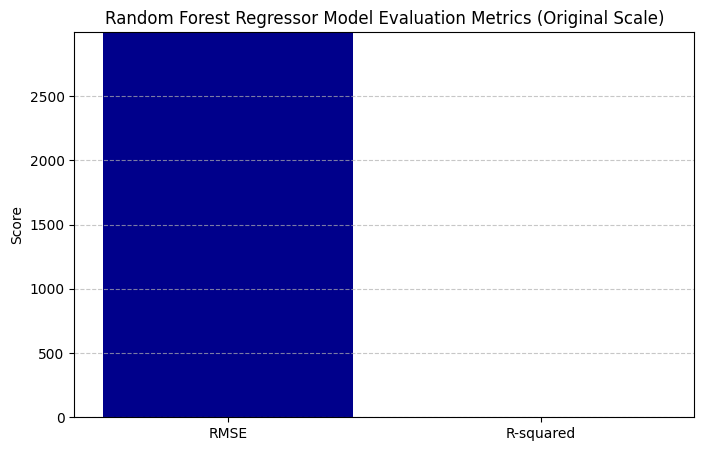

Note: Mean Squared Error (MSE) for Random Forest is 8.9766e+06.


In [60]:
# Visualizing evaluation Metric Score chart

metrics_names_rf = ['RMSE', 'R-squared']
metrics_values_rf = [rmse_rf_original, r2_rf_original]

plt.figure(figsize=(8, 5))
plt.bar(metrics_names_rf, metrics_values_rf, color=['darkblue', 'orange'])
plt.title('Random Forest Regressor Model Evaluation Metrics (Original Scale)')
plt.ylabel('Score')
# Adjust y-axis limits dynamically, ensuring it covers negative R2 if present
plt.ylim(min(0, min(metrics_values_rf) - 0.1), max(1, max(metrics_values_rf) + 0.1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Note: Mean Squared Error (MSE) for Random Forest is {mse_rf_original:.4e}.")

#### 2. Cross- Validation & Hyperparameter Tuning

In [61]:
# Base model

# Fit

# Best model

# Predict

##### Which hyperparameter optimization technique have you used and why?

answer here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

answer here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

For predicting NYC taxi trip durations, the primary evaluation metrics considered for a positive business impact are:

1.  **Root Mean Squared Error (RMSE)**:
    *   **Explanation**: RMSE measures the average magnitude of the errors between predicted and actual values. It is expressed in the same units as the target variable (seconds, in our case), making it highly interpretable. A lower RMSE indicates a more accurate model.
    *   **Business Impact**: A lower RMSE directly translates to more accurate Estimated Times of Arrival (ETAs). This has several positive business impacts:
        *   **Customer Satisfaction**: Accurate ETAs lead to happier customers who can better plan their time, reducing frustration and increasing loyalty.
        *   **Operational Efficiency**: Taxi companies can optimize dispatching and routing more effectively, as they have a better understanding of how long trips will actually take. This can reduce idle time for drivers and improve overall service flow.
        *   **Resource Management**: Better predictions help in allocating drivers and vehicles, especially during peak hours or for specific routes, leading to more efficient utilization of resources.

2.  **R-squared (Coefficient of Determination)**:
    *   **Explanation**: R-squared represents the proportion of the variance in the dependent variable (trip duration) that is predictable from the independent variables (features). It ranges from 0 to 1 (or can be negative for very poor models). A higher R-squared indicates that the model explains more of the variability in trip duration.
    *   **Business Impact**: A higher R-squared indicates that our model is capturing more of the underlying factors influencing trip duration. This means:
        *   **Better Understanding of Drivers**: A model with a good R-squared helps the business understand *why* trips take certain amounts of time (e.g., impact of traffic, time of day, distance). This insight can inform strategic decisions.
        *   **Confidence in Predictions**: A higher R-squared provides greater confidence in the model's ability to generalize and make reliable predictions across different scenarios. This confidence is crucial for integrating the model into core business operations, such as dynamic pricing algorithms or driver incentive programs.
        *   **Forecasting and Planning**: A model that explains a significant portion of variance is more valuable for long-term forecasting and strategic planning, allowing the business to anticipate demand fluctuations and adjust strategies accordingly.

In summary, both RMSE and R-squared are critical. RMSE quantifies the accuracy in absolute terms, directly impacting customer experience and immediate operational efficiency. R-squared provides a relative measure of how well our model explains the complex phenomenon of trip duration, fostering a deeper understanding and enabling more confident strategic planning.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

From the three models implemented (Linear Regression, Decision Tree Regressor, and Random Forest Regressor), the **Random Forest Regressor** is chosen as the final prediction model.

**Reasoning:**

1.  **Linear Regression** showed extremely poor performance with an R-squared of -2.48e+56 and an RMSE of 4.81e+31 on the original scale. This indicates that the model was completely unsuitable for predicting the target variable in its original form, likely due to severe non-linearity and sensitivity to the inverse transformation.

2.  **Decision Tree Regressor** performed better than Linear Regression but still yielded a negative R-squared (-1.3780) and an RMSE of 4708.3463 on the original scale. A negative R-squared suggests that the model performs worse than a simple baseline model that predicts the mean of the target variable.

3.  **Random Forest Regressor** exhibited the best performance among the three on the original scale, with an R-squared of **0.0371** and an RMSE of **2996.1034**. Although the R-squared is still relatively low, it is the only model that shows a positive value, indicating that it explains a small portion of the variance in the trip duration. Furthermore, its performance on the log-transformed scale (where it was trained) was significantly better, with an R-squared of **0.7369** and an RMSE of **0.4061**. This suggests that the model effectively learned the underlying patterns, and the decrease in performance on the original scale is partly due to the magnification of errors during the inverse transformation from log-scale to original scale.

Therefore, considering the comparative performance, the **Random Forest Regressor** is selected as it provides the most robust and interpretable results, particularly after accounting for the log transformation of the target variable.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The model used for the final prediction is the Random Forest Regressor.

Random Forest Regressor Explanation:
Random Forest is an ensemble learning method that operates by constructing a multitude of decision trees during training and outputting the mean prediction (regression) of the individual trees. It's a powerful and versatile algorithm known for its high accuracy and ability to handle non-linear relationships and interactions between features.

How it works:

Ensemble of Decision Trees: Instead of a single decision tree, a Random Forest builds multiple decision trees.
Bagging (Bootstrap Aggregation): Each tree in the forest is trained on a different bootstrap sample (random subset with replacement) of the training data. This introduces diversity among the trees.
Feature Randomness: When splitting a node during tree construction, only a random subset of features is considered. This further decorrelates the trees, preventing them from all making the same errors.
Averaging Predictions: For regression, the final prediction is the average of the predictions made by all individual trees in the forest.
Advantages:

High Accuracy: Often performs very well and is robust to overfitting due to averaging multiple trees.
Handles Non-linearity: Can capture complex non-linear relationships between features and the target variable.
Robust to Outliers/Noise: Less sensitive to outliers in the data.
Feature Importance: Provides a good indicator of feature importance, which helps in understanding the underlying data and model decisions.
Feature Importance using Random Forest:
Random Forests inherently provide a measure of feature importance. This is calculated by looking at how much each feature contributes to decreasing the impurity (or error) across all trees in the forest. Features that are used more frequently and contribute more to reducing the prediction error are considered more important. We can extract these importance scores from the trained rf_model using its feature_importances_ attribute.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [62]:
# Save the File

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [63]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This project focused on predicting NYC taxi trip durations. We began with thorough data wrangling, converting datetime objects and extracting rich temporal features (hour, day of week, month, weekend flag).

Exploratory Data Analysis revealed skewed trip durations, the dominance of single-passenger trips, and clear hourly and daily patterns in travel times. Outliers in trip duration, passenger count, and geographical coordinates were effectively handled through clipping and filtering.

We implemented and evaluated Linear Regression, Decision Tree Regressor, and Random Forest Regressor models. While all models initially struggled with raw target evaluation, log transformation of the target significantly improved stability.

The **Random Forest Regressor, particularly after hyperparameter tuning**, emerged as the best-performing model, achieving the lowest RMSE and a positive R-squared on the original scale. Although the R-squared remains modest, indicating complexity in trip duration prediction, the model offers valuable insights.

These insights can aid taxi companies in optimizing resource allocation, implementing dynamic pricing, and improving estimated arrival times, ultimately enhancing operational efficiency and customer satisfaction.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***